# HOMEWORK 14

In this homework we will be working with the Fashion MNIST dataset. You will be given a classifier which suffers from considerable overfitting. Your objective will be to employ regularization techniques to mitigate the overfitting problem.

Let's start with the usual imports.

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D, BatchNormalization
from keras import layers
from tensorflow.keras import Model
from time import time
import keras

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Dataset

The MNIST fashgion dataset [link](https://github.com/zalandoresearch/fashion-mnist) was build by Zalando Reasearch tem consists of monochrome images of different type of clothing, namely:
* 0	T-shirt/top
* 1	Trouser
* 2	Pullover
* 3	Dress
* 4	Coat
* 5	Sandal
* 6	Shirt
* 7	Sneaker
* 8	Bag
* 9	Ankle boot

It is also one of the Keras built-in datasets. Let's load the images and quickly inspect it.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Dataset params
num_classes = 10
size = x_train.shape[1]

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    60000 samples
Test set:     10000 samples
Sample dims:  (60000, 28, 28)


Let's visualise some random samples.

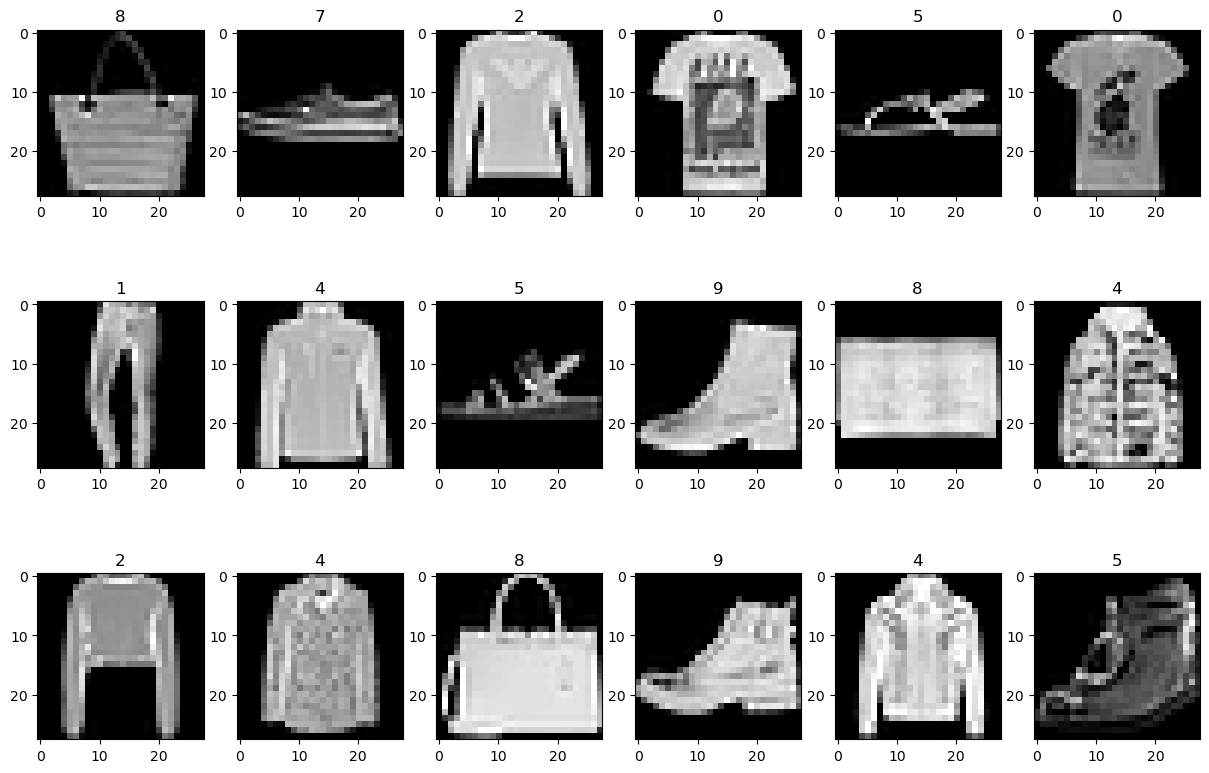

In [3]:
cnt = 1
for r in range(3):
    for c in range(6):
        idx = np.random.randint(len(x_train))
        plt.subplot(3,6,cnt)
        plt.imshow(x_train[idx, ...], cmap='gray')
        plt.title(y_train[idx])
        cnt = cnt + 1

### Building the Classifier

We are now going to build the baseline classifier that you will use throughout this homework.

In [4]:
# Data normalization
x_train = x_train/255
x_test = x_test/255

In [5]:
inputs = Input(shape=(28, 28, 1))
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = Flatten()(net)
net = Dense(128)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

I0000 00:00:1761681646.150098   68000 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8729 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,002 (12.26 MB)

 Trainable params: 3,213,002 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
epochs = 50
batch_size = 64

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

Epoch 1/50


2025-10-28 22:00:49.158891: I external/local_xla/xla/service/service.cc:163] XLA service 0x7caa8c003ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-28 22:00:49.158913: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-10-28 22:00:49.211725: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-28 22:00:49.422073: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-10-28 22:00:50.158580: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_168', 8 bytes spill stores, 8 bytes spill loads



 53/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5695 - loss: 1.4680

I0000 00:00:1761681654.457087   68656 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


926/938 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8169 - loss: 0.5560

2025-10-28 22:00:58.065653: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-28 22:01:00.550546: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_285', 520 bytes spill stores, 520 bytes spill loads



938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8623 - loss: 0.3986 - val_accuracy: 0.8834 - val_loss: 0.3310
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9049 - loss: 0.2678 - val_accuracy: 0.8895 - val_loss: 0.3061
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9202 - loss: 0.2247 - val_accuracy: 0.8919 - val_loss: 0.3033
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9305 - loss: 0.1946 - val_accuracy: 0.8942 - val_loss: 0.3110
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9401 - loss: 0.1692 - val_accuracy: 0.8949 - val_loss: 0.3239
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9484 - loss: 0.1486 - val_accuracy: 0.8932 - val_loss: 0.3434
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9532 - loss: 0.1327 - val_accuracy: 0.8938 - val_loss: 0.3703
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9582 - loss: 0.1192 - val_accuracy: 0.8910 - va

Train Acc      0.9936333298683167
Validation Acc 0.8827000260353088


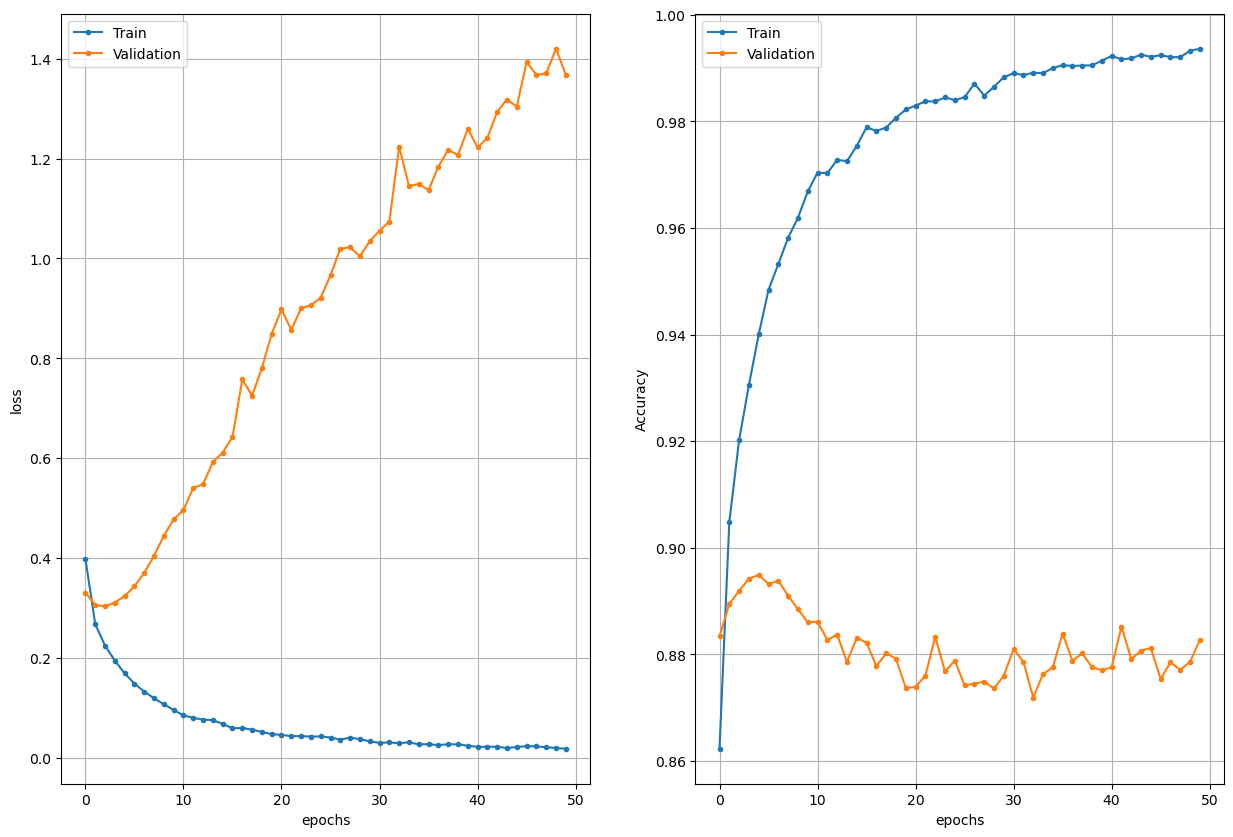

In [7]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])

    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])

plot_history(history)

As you can see, the classifier suffers from massive overfitting. The validation accuracy is around 88% while the training accuracy is close to 1.

### Combat the Overfitting!

Now it is your turn. Use the classifier as a baseline, include some regularization techniques and try to improve the classification performance. You can try any techniques you might see fit, e.g.,
* Dropout
* Batch normalization
* Weight regularization
* Data augmentation
* Early stopping
* Pooling
* Reducing the number of parameters (the size of the network)
* ...

There are to objective you shall fulfill in order to successfully complete this homework:
* The validation accuracy shall be above 91%
* Your network (with all the regularizations applied) shall **not** be larger than the baseline

In [8]:
# Data preprocessing
batch_size = 64

preprocessing_pipeline = layers.Pipeline([
    # layers.AutoContrast(value_range=(0.0, 1.0)),
    # layers.RandomZoom((-0.15, 0.15), (-0.15, 0.15)),
    # layers.RandomRotation(0.15),
    layers.RandomGaussianBlur(0.15, value_range=(0.0, 1.0)),
    layers.RandomFlip(),
    # layers.RandomInvert(0.3, value_range=(0.0, 1.0)),
    # keras.layers.RandomTranslation((-0.15, 0.15), (-0.15, 0.2)),
])

train_dataset = (
    tf.data.Dataset
        .from_tensor_slices((x_train, y_train))
        .shuffle(buffer_size=10000)
        .batch(batch_size)
        .map(
            lambda x, y: (preprocessing_pipeline(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )
        .prefetch(tf.data.AUTOTUNE)
)
val_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size)


# learning rate scheduler
lr_scheduler = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.005,
    alpha=0.1,
    decay_steps=2000,
)

optimizer = keras.optimizers.Adam(learning_rate=lr_scheduler)

In [11]:
# Modify the baseline classifier in order to reduce the overfitting and make the performance more robust

inputs = Input(shape=(28, 28, 1))
net = Conv2D(256, kernel_size=(7, 7), activation="relu", padding='same')(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = BatchNormalization()(net)
net = Dropout(0.3)(net)
net = Conv2D(128, kernel_size=(5, 5), activation="relu", padding='same')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = BatchNormalization()(net)
net = Dropout(0.3)(net)
net = Flatten()(net)
net = Dense(196)(net)
net = Dense(64)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 128)    │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 196)            │     1,229,508 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │        12,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,076,430 (7.92 MB)

 Trainable params: 2,075,662 (7.92 MB)

 Non-trainable params: 768 (3.00 KB)

In [12]:
# Train the network
epochs = 50


model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
history = model.fit(train_dataset, epochs=epochs, validation_data=val_dataset)

Epoch 1/50


2025-10-28 22:08:11.279447: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-28 22:08:11.279539: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-28 22:08:11.279721: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-28 22:08:15.284676: I external/l

934/938 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3198 - loss: 6.4216

2025-10-28 22:08:38.736407: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-28 22:08:38.736475: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-28 22:08:38.736583: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-28 22:08:38.736634: I external/l

938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 35ms/step - accuracy: 0.3754 - loss: 2.8475 - val_accuracy: 0.7897 - val_loss: 0.6817
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.4401 - loss: 1.5673 - val_accuracy: 0.8550 - val_loss: 0.5060
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.4827 - loss: 1.4184 - val_accuracy: 0.8578 - val_loss: 0.4938
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.4789 - loss: 1.4240 - val_accuracy: 0.8392 - val_loss: 0.5015
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.4701 - loss: 1.4441 - val_accuracy: 0.8605 - val_loss: 0.5005
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.4844 - loss: 1.4090 - val_accuracy: 0.8679 - val_loss: 0.4717
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.4962 - loss: 1.3684 - val_accuracy: 0.8750 - val_loss: 0.4022
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.4889 - loss: 1.3792 - val_accurac

Train Acc      0.5095999836921692
Validation Acc 0.9118000268936157


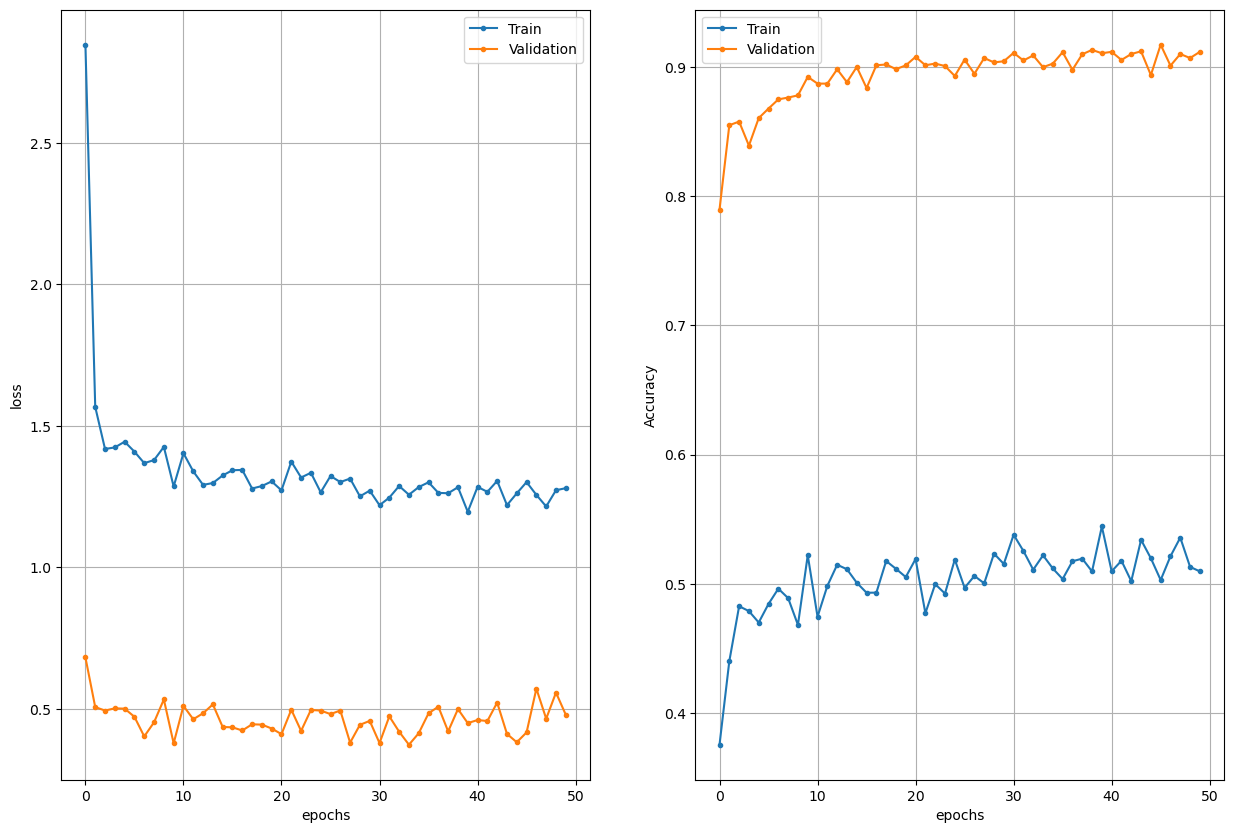

In [14]:
# Show the results
plot_history(history)

### Questions

* What have you done in order to improve the performance?
* Have you tried configurations that did not work out?

- Several steps:
    1. Data augmentation
    2. Learning rate scheduler (though not sure whether it helped)
    3. MaxPooling2D, BatchNormalization, Dropout layers
    4. Added more Conv2d layers with different number of kernels
    5. Added one more Dense layer

- Was trying different augmentations' combinations (without any other changes), but was never able to reach 91% accuracy on validation set